# Leukemia Risk Prediction


The goal is to **predict disease risk for patients with blood cancer**, in the context of specific subtypes of adult myeloid leukemias.

The risk is measured through the **overall survival** of patients, i.e. the duration of survival from the diagnosis of the blood cancer to the time of death or last follow-up.

Estimating the prognosis of patients is critical for an optimal clinical management. 
For exemple, patients with low risk-disease will be offered supportive care to improve blood counts and quality of life, while patients with high-risk disease will be considered for hematopoietic stem cell transplantion.

The performance metric used in the challenge is the **IPCW-C-Index**.

- OUTCOME:
  * OS_YEARS = Overall survival time in years
  * OS_STATUS = 1 (death) , 0 (alive at the last follow-up)

- CLINICAL DATA, with one line per patient:
  
  * ID = unique identifier per patient
  * CENTER = clinical center
  * BM_BLAST = Bone marrow blasts in % (blasts are abnormal blood cells)
  * WBC = White Blood Cell count in Giga/L 
  * ANC = Absolute Neutrophil count in Giga/L
  * MONOCYTES = Monocyte count in Giga/L
  * HB = Hemoglobin in g/dL
  * PLT = Platelets coutn in Giga/L
  * CYTOGENETICS = A description of the karyotype observed in the blood cells of the patients, measured by a cytogeneticist. Cytogenetics is the science of chromosomes. A karyotype is performed from the blood tumoral cells. The convention for notation is ISCN (https://en.wikipedia.org/wiki/International_System_for_Human_Cytogenomic_Nomenclature). Cytogenetic notation are: https://en.wikipedia.org/wiki/Cytogenetic_notation. Note that a karyotype can be normal or abnornal. The notation 46,XX denotes a normal karyotype in females (23 pairs of chromosomes including 2 chromosomes X) and 46,XY in males (23 pairs of chromosomes inclusing 1 chromosme X and 1 chromsome Y). A common abnormality in the blood cancerous cells might be for exemple a loss of chromosome 7 (monosomy 7, or -7), which is typically asssociated with higher risk disease

- GENE MOLECULAR DATA, with one line per patient per somatic mutation. Mutations are detected from the sequencing of the blood tumoral cells. 
We call somatic (= acquired) mutations the mutations that are found in the tumoral cells but not in other cells of the body.

  * ID = unique identifier per patient
  * CHR START END = position of the mutation on the human genome
  * REF ALT = reference and alternate (=mutant) nucleotide
  * GENE = the affected gene
  * PROTEIN_CHANGE = the consequence of the mutation on the protei that is expressed by a given gene
  * EFFECT = a broad categorization of the mutation consequences on a given gene.
  * VAF = Variant Allele Fraction = it represents the **proportion** of cells with the deleterious mutations. 

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import re

from scipy.stats import spearmanr


from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest, ExtraSurvivalTrees, GradientBoostingSurvivalAnalysis, ComponentwiseGradientBoostingSurvivalAnalysis
from sksurv.svm import FastSurvivalSVM
from sksurv.metrics import concordance_index_ipcw
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

import torch
import torchtuples as tt
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv

from sksurv.nonparametric import kaplan_meier_estimator


# Clinical Data
clin_train = pd.read_csv("clinical_train.csv")
clin_test= pd.read_csv("clinical_test.csv")

# Molecular Data
mol_train = pd.read_csv("molecular_train.csv")
mol_test = pd.read_csv("molecular_test.csv")

target_df = pd.read_csv("target_train.csv")

print(f"clin_train : {clin_train.shape}")
print(f"clin_test  : {clin_test.shape}")
print(f"mol_train : {mol_train.shape}")
print(f"mol_test  : {mol_test.shape}")

clin_train : (3323, 9)
clin_test  : (1193, 9)
mol_train : (10935, 11)
mol_test  : (3089, 11)


In [462]:
target_df.head()

,ID,OS_YEARS,OS_STATUS
0,P132697,1.115068,1.0
1,P132698,4.928767,0.0
2,P116889,2.043836,0.0
3,P132699,2.476712,1.0
4,P132700,3.145205,0.0


In [463]:
pd.reset_option('all')

C:\Users\lea.coquet\AppData\Local\Temp\ipykernel_20000\2786130087.py:1: FutureWarning: data_manager option is deprecated and will be removed in a future version. Only the BlockManager will be available.
  pd.reset_option('all')
C:\Users\lea.coquet\AppData\Local\Temp\ipykernel_20000\2786130087.py:1: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.reset_option('all')


# Step1 : Exploratory Analysis

In [2]:
clin_train.head()

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]"
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,"46,xx"
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]"
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]"
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]"


In [3]:
pd.set_option('display.max_rows', None)
clin_test['CYTOGENETICS']

0                     47,XY,+X,del(9)(q?)[15]/47,XY,+X[5]
1       46,XY,der(3)?t(3;11)(q26.2;q23),add(4)(p15).de...
2                                                47,XX,+8
3                                                  Normal
4       43,XY,dic(5;17)(q11.2;p11.2),-7,-13,-20,-22,+r...
5                                                  Normal
6                                       46,XY,del(11)(q?)
7                                46,XY,del(5)(q13q15)[20]
8                                                  Normal
9                                                47,XY,+8
10                                                 Normal
11                          45,XX,-7,[19/20]/46,XX,[1/20]
12                                                 Normal
13                                                 Normal
14                                                 Normal
15                                 Abnormal(not examined)
16                                                 Normal
17            

In [4]:
mol_train.head()

,ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
0,P100000,11,119149248.0,119149248.0,G,A,CBL,p.C419Y,non_synonymous_codon,0.0830,1308.0
1,P100000,5,131822301.0,131822301.0,G,T,IRF1,p.Y164*,stop_gained,0.0220,532.0
2,P100000,3,77694060.0,77694060.0,G,C,ROBO2,p.?,splice_site_variant,0.4100,876.0
3,P100000,4,106164917.0,106164917.0,G,T,TET2,p.R1262L,non_synonymous_codon,0.4300,826.0
4,P100000,2,25468147.0,25468163.0,ACGAAGAGGGGGTGTTC,A,DNMT3A,p.E505fs*141,frameshift_variant,0.0898,942.0


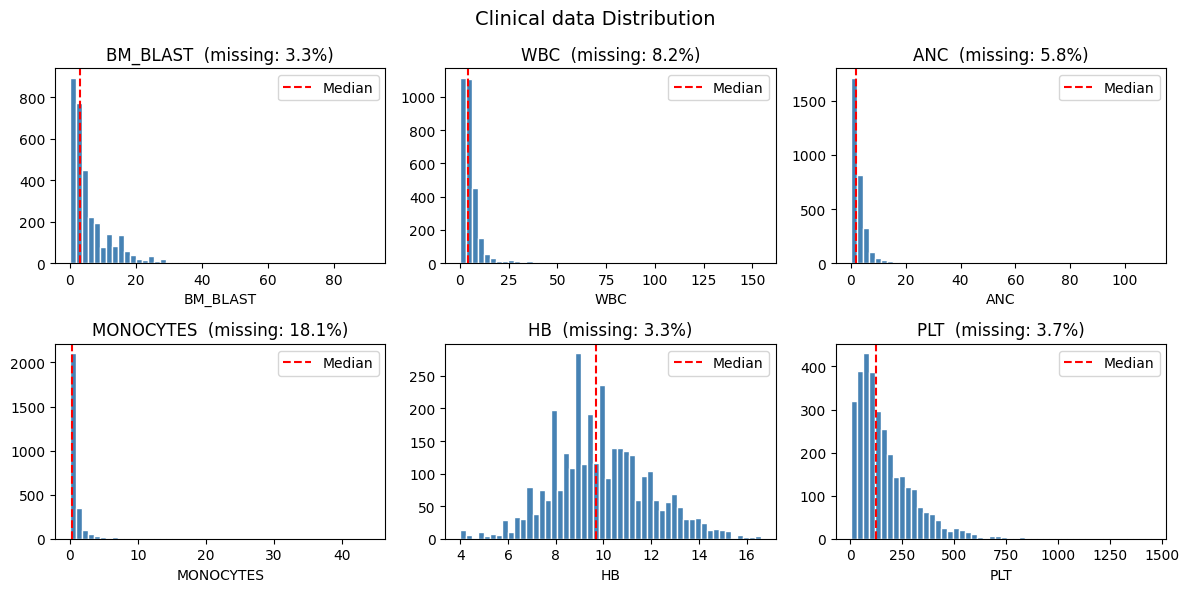

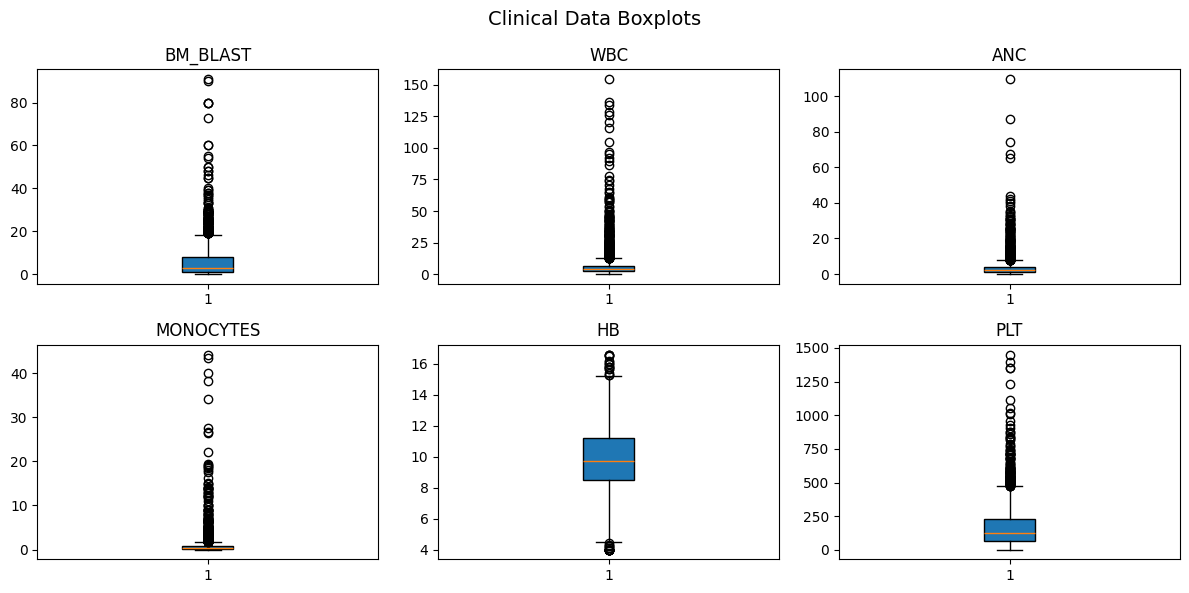

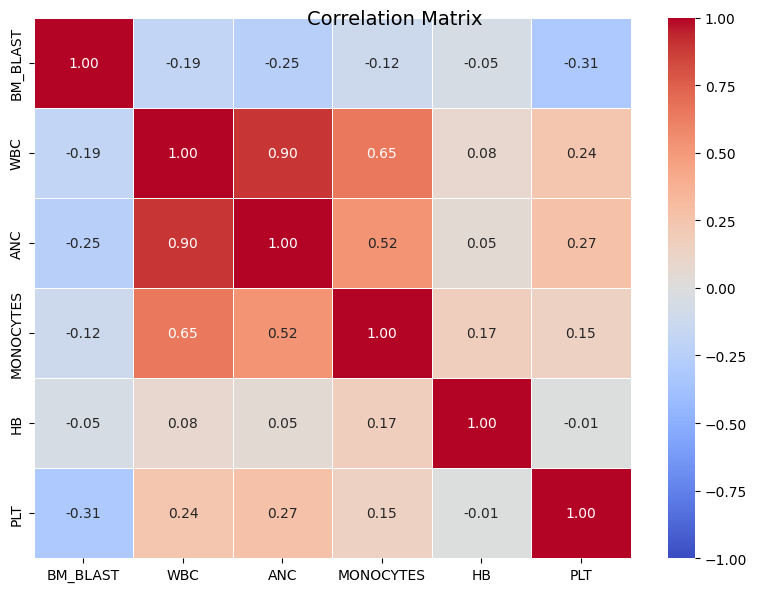

In [5]:
NUM_COLS = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']

# Columns distributions and missing values
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, col in zip(axes.flat, NUM_COLS):
    ax.hist(clin_train[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    ax.set_title(f'{col}  (missing: {clin_train[col].isnull().mean()*100:.1f}%)')
    ax.set_xlabel(col)
    ax.axvline(clin_train[col].median(), color='red', linestyle='--', label='Median')
    ax.legend()
plt.suptitle("Clinical data Distribution", fontsize=14)
plt.tight_layout()
plt.show()

# Boxplots
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, col in zip(axes.flat, NUM_COLS):
    ax.boxplot(clin_train[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict())
    ax.set_title(col)
plt.suptitle("Clinical Data Boxplots", fontsize=14)
plt.tight_layout()
plt.show()

# Correlation matrix
corr = clin_train[NUM_COLS].corr(method='spearman')
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, linewidths=0.5)
plt.tight_layout()
plt.suptitle("Correlation Matrix", fontsize=14)
plt.show()

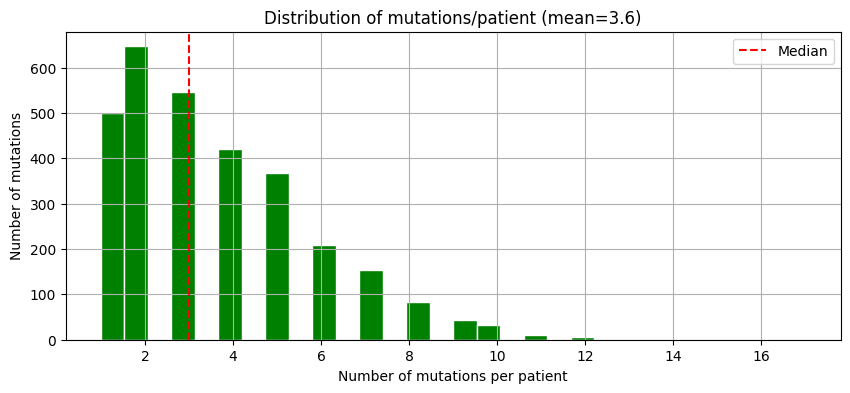

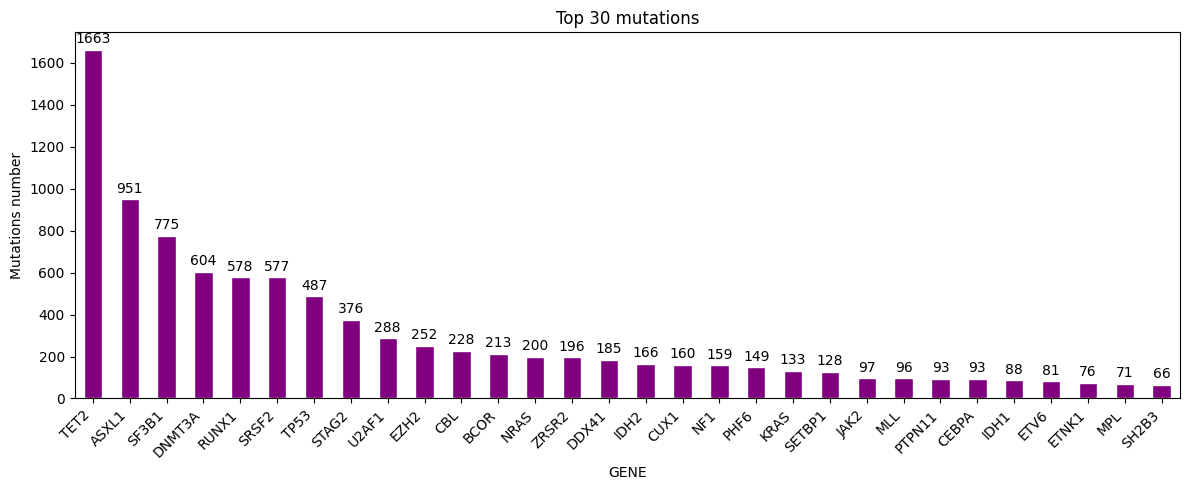

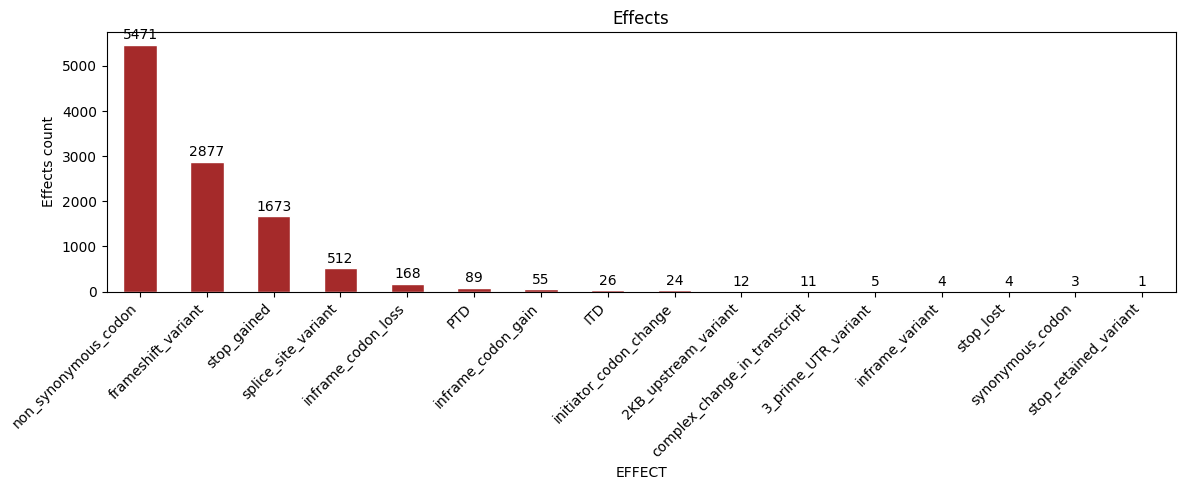

C:\Users\lea.coquet\AppData\Local\Temp\ipykernel_33152\2709008767.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


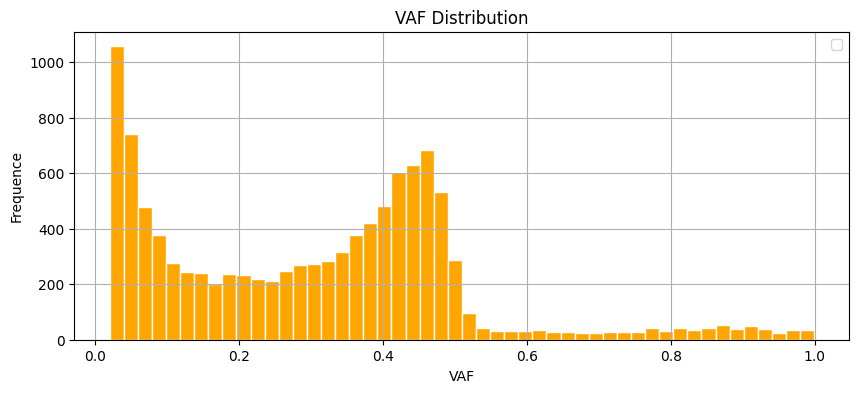

In [6]:
# Mutations per patient
mut_per_patient = mol_train.groupby('ID').size()
plt.figure(figsize=(10, 4))
mut_per_patient.hist(bins=30, color='green', edgecolor='white')
plt.xlabel("Number of mutations per patient")
plt.ylabel("Number of mutations")
plt.title(f"Distribution of mutations/patient (mean={mut_per_patient.mean():.1f})")
plt.axvline(mut_per_patient.median(), color='red', linestyle='--', label='Median')
plt.legend()
plt.show()

# Top 30 mutations
top_genes = mol_train['GENE'].value_counts().head(30)
plt.figure(figsize=(12, 5))
ax = top_genes.plot.bar(color='purple', edgecolor='white')
for i, v in enumerate(top_genes.values):
    ax.text(i, v + (max(top_genes.values) * 0.01), str(v), ha='center', va='bottom', fontsize=10)
plt.title("Top 30 mutations")
plt.ylabel("Mutations number")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Effects
top_effects = mol_train['EFFECT'].value_counts()
plt.figure(figsize=(12, 5))
ax = top_effects.plot.bar(color='brown', edgecolor='white')
for i, v in enumerate(top_effects.values):
    ax.text(i, v + (max(top_effects.values) * 0.01), str(v), ha='center', va='bottom', fontsize=10)
plt.title("Effects")
plt.ylabel("Effects count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# VAF Distribution
plt.figure(figsize=(10, 4))
mol_train['VAF'].hist(bins=50, color='orange', edgecolor='white')
plt.title("VAF Distribution")
plt.xlabel("VAF")
plt.ylabel("Frequence")
plt.legend()
plt.show()

# Step 2 : Clinical Data Preparation

In [7]:
def prepare_clinical(df, clin_medians=None, fit=True):
    """
    clin_medians : medians computed on the train, to apply on the test with fit=False
    """
    df = df.copy()
    NUM_COLS = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']

    # Median imputation per center, then global if not found
    if fit:
        clin_medians = {}
        clin_medians['global'] = df[NUM_COLS].median()
        clin_medians['by_center'] = df.groupby('CENTER')[NUM_COLS].median()
        print(clin_medians)
    
    for col in NUM_COLS:
        center_fill = df['CENTER'].map(clin_medians['by_center'][col].to_dict())
        global_fill = clin_medians['global'][col]
        df[col] = df[col].fillna(center_fill).fillna(global_fill)

    # Capping at P1 and P99 to avoid outliers and extreme data
    if fit:
        clin_medians['p01'] = df[NUM_COLS].quantile(0.01)
        clin_medians['p99'] = df[NUM_COLS].quantile(0.99)

    for col in NUM_COLS:
        df[col] = df[col].clip(
            lower=clin_medians['p01'][col],
            upper=clin_medians['p99'][col]
        )

    return df, clin_medians

clin_train_clean, clin_medians = prepare_clinical(clin_train, fit=True)
clin_test_clean, _           = prepare_clinical(clin_test, clin_medians=clin_medians, fit=False)

print("Missing values after imputation (train): ", clin_train_clean[['BM_BLAST','WBC','ANC','MONOCYTES','HB','PLT']].isnull().sum())

{'global': BM_BLAST       3.00
WBC            4.10
ANC            2.00
MONOCYTES      0.37
HB             9.70
PLT          123.00
dtype: float64, 'by_center':         BM_BLAST    WBC      ANC  MONOCYTES     HB    PLT
CENTER                                                   
CCH         3.00  4.580  2.70000      0.410  10.40  146.0
CGM         3.40  4.200  1.97200      0.298   8.20  108.0
DUS         3.00  3.800  1.75875      0.304   9.70  124.5
DUTH        7.00  4.660  1.99000      0.340   9.90   98.5
FLO         0.00  4.455  2.20800      0.378  10.00  139.0
FUCE        0.00  3.245  1.20000      0.360   7.70  116.0
GESMD       3.00  5.000  2.52000      0.460   9.60  163.0
HIAE        2.80  3.830  1.91000      0.320   9.30   81.0
HMS         4.00  3.800  1.30000      0.300   9.30   75.0
ICO         2.00  4.800  2.16000      0.495  10.10  152.0
IHBT        6.00  3.390  1.25000      0.675   9.20  112.0
KI          3.00  4.300  2.00000      0.400  10.00  123.0
MSK         6.00  2.800  1.2

In [8]:
# Adding new features to the clinical data

def add_clinical_features(df):
    df = df.copy()

    # Log transformation of asymetric distributions for COX model
    for col in ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'PLT']:
        df[f'log_{col}'] = np.log1p(df[col])  # log(1+x) for 0 values

    # Biological ratios
    df['ratio_ANC_WBC']  = df['ANC']       / (df['WBC']  + 1e-6) # proportion of neutrophils among white blood cells
    df['ratio_MONO_WBC'] = df['MONOCYTES'] / (df['WBC']  + 1e-6) # proportion of monocytes among white blood cells
    df['ratio_PLT_WBC']  = df['PLT']       / (df['WBC']  + 1e-6) # proportion of thrombocytes among white blood cells

    # Clinical flags with medical thresolds
    df['flag_high_blast']       = (df['BM_BLAST'] >= 20).astype(int)
    df['flag_leukocytosis']     = (df['WBC']      > 10.0).astype(int)
    df['flag_neutropenia']      = (df['ANC']      < 1.5).astype(int)
    df['flag_anemia']           = (df['HB']       < 12.0).astype(int)
    df['flag_thrombocytopenia'] = (df['PLT']      < 150).astype(int)
    
    # Blast categorisation
    # < 5%  : Normal
    # 5-10% : Excess blasts 1
    # 10-20%: Excess blasts 2
    # ≥ 20% : Acute myeloid leukemia
    df['blast_category'] = pd.cut(df['BM_BLAST'], bins=[-0.1, 5, 10, 20, 100], labels=[0, 1, 2, 3]).astype(int)

    return df

clin_train_feat = add_clinical_features(clin_train_clean)
clin_test_feat  = add_clinical_features(clin_test_clean)

print(f"clin_train_feat : {clin_train_feat.shape}")
print(f"clin_test_feat  : {clin_test_feat.shape}")

clin_train_feat.head()

clin_train_feat : (3323, 23)
clin_test_feat  : (1193, 23)


,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,log_BM_BLAST,...,log_PLT,ratio_ANC_WBC,ratio_MONO_WBC,ratio_PLT_WBC,flag_high_blast,flag_leukocytosis,flag_neutropenia,flag_anemia,flag_thrombocytopenia,blast_category
0,P132697,MSK,14.0,2.80,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",2.708050,...,4.787492,0.071429,0.250000,42.499985,0,0,1,1,1,2
1,P132698,MSK,1.0,7.40,2.4,0.1,11.6,42.0,"46,xx",0.693147,...,3.761200,0.324324,0.013514,5.675675,0,0,0,1,1,0
2,P116889,MSK,15.0,3.70,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",2.772589,...,4.406719,0.567567,0.027027,21.891886,0,0,0,0,1,2
3,P132699,MSK,1.0,3.90,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]",0.693147,...,4.356709,0.487179,0.025641,19.743585,0,0,0,1,1,0
4,P132700,MSK,6.0,47.68,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",1.945910,...,5.278115,0.203440,0.018876,4.089765,0,1,0,1,0,1


In [9]:
def parse_cytogenetics(df):
    df = df.copy()
    cyto = df['CYTOGENETICS'].fillna('').str.lower().str.strip()

    ## Missing data
    is_not_evaluated = cyto.str.contains(r'not evaluated|not done|unknown|failed', case=False)
    df['cyto_missing'] = (df['CYTOGENETICS'].isnull() | is_not_evaluated).astype(int)

    ## Normal Caryotype
    df['cyto_is_normal'] = (cyto.str.match(r'^46,\s*(xx|xy)\s*(\[\d+\])?$', case=False) | (cyto == 'normal')).astype(float)

    ## Structural Anomaly
    df['cyto_has_deletion']      = cyto.str.contains(r'del\(',  case=False).astype(float)
    df['cyto_has_translocation'] = cyto.str.contains(r't\(\d',  case=False).astype(float)
    df['cyto_has_inversion']     = cyto.str.contains(r'inv\(',  case=False).astype(float)
    df['cyto_has_duplication']   = cyto.str.contains(r'dup\(',  case=False).astype(float)
    df['cyto_has_monosomy']      = cyto.str.contains(r',-\d+|,-\s*x|,-\s*y|monosomy|mono\d+', case=False).astype(float) # Strong signal of chromosomal instability
    df['cyto_has_trisomy']       = df['cyto_has_trisomy'] = cyto.str.contains(r'\+\d+|\+x|\+y|trisomy|trisomia|tris\d+', case=False).astype(float)

    # Nouvelles extractions pour les marqueurs et matériel additionnel
    df['cyto_has_marker']        = cyto.str.contains(r'\+mar', case=False).astype(float) # Chromosome marqueur
    df['cyto_has_add']           = cyto.str.contains(r'add\(', case=False).astype(float) # Matériel additionnel non identifié
    df['cyto_has_dic']           = cyto.str.contains(r'dic\(', case=False).astype(float) # Chromosome dicentrique (instabilité ++)

    ## Partial deletions
    df['cyto_del5q']  = cyto.str.contains(r'del\(5',  case=False).astype(float)  # Good : responsive to lenalidomide treatment
    df['cyto_del7q']  = cyto.str.contains(r'del\(7',  case=False).astype(float)  # Intermediate from  IPSS-R
    df['cyto_del20q'] = cyto.str.contains(r'del\(20', case=False).astype(float)  # Good
    df['cyto_del17p'] = cyto.str.contains(r'del\(17p|del\(17\)\(p', case=False).astype(float)  # Bad: contains TP53

    ## Specific Monosomy
    df['cyto_monosomy7']  = df['cyto_monosomy7'] = cyto.str.contains(r'-7(?!\d)|monosomy\s*7|mono\s*7', case=False).astype(float)  # loss of anti-tumor protection
    df['cyto_monosomy5']  = df['cyto_monosomy7'] = cyto.str.contains(r'-5(?!\d)|monosomy\s*5|mono\s*5', case=False).astype(float)  # cell cycle genes
    df['cyto_monosomy17'] = df['cyto_monosomy7'] = cyto.str.contains(r'-17(?!\d)|monosomy\s*17|mono\s*17', case=False).astype(float)  # TP53 = genom guradian (accumulation of unrepaired mutations, massive resistance to chemotherapy)

    ## Specific Trisomy
    df['cyto_plus8'] = cyto.str.contains(r'\+8(?!\d)|trisomy\s*8|tris\s*8|trisomia\s*8', case=False).astype(float)  # Intermediate from IPSS-R

    ## Translocation and inversion
    df['cyto_t821']  = cyto.str.contains(r't\(8;21\)',  case=False).astype(float)  # favorable prognosis (sensitive to chemotherapy)
    df['cyto_inv16'] = cyto.str.contains(r'inv\(16\)',  case=False).astype(float)  # favorable prognosis (sensitive to chemotherapy)
    df['cyto_t1517'] = cyto.str.contains(r't\(15;17\)', case=False).astype(float)  # favorable prognosis
    df['cyto_inv3_t33'] = (cyto.str.contains(r'inv\(3\)', case=False) | cyto.str.contains(r't\(3;3\)', case=False)).astype(float)  # Very bad: activates proliferation and inhibits apoptosis

    ## Caryotype complexity
    anomaly_sum = (df['cyto_has_deletion'] +df['cyto_has_translocation'] +df['cyto_has_inversion'] +df['cyto_has_duplication'] +df['cyto_has_monosomy']
                   +df['cyto_has_trisomy']+df['cyto_has_marker'] + df['cyto_has_add'] + df['cyto_has_dic'])
    
    is_complex_text = cyto.str.contains(r'complex|abnormalities|>3|abnormal', case=False)
    df['cyto_n_anomalies'] = np.where(is_complex_text, np.maximum(anomaly_sum, 3.0), anomaly_sum)
    df['cyto_is_complex']  = (df['cyto_n_anomalies'] >= 3).astype(float)  # Bad: strong chromosomal instability

    ## Number of clones (count of /)
    df['cyto_n_clones'] = cyto.str.count('/') + 1
    df.loc[df['CYTOGENETICS'].isnull(), 'cyto_n_clones'] = np.nan

    # Clonal proportion of abnormal cells
    # Ex : "46,xy,del(20)(q12)[2]/46,xy[18]" → 2/(2+18) = 0.10
    # Ex : "46,xy,del(7q)[20]"                → 1.00  (all cells)
    # Ex : "46,xy"  (normal)    → 0.00  (no abnormal cell)

    all_counts_raw = cyto.str.extractall(r'\[(\d+)\]')[0].astype(float) # sum of all [n] in the chain
    total_counts   = all_counts_raw.groupby(level=0).sum().reindex(df.index, fill_value=0)

    last_seg = cyto.str.split('/').str[-1].str.strip() # last segment after last "/"
    last_is_normal = last_seg.str.match(r'^46,\s*(xx|xy)', case=False) # is the last clone normal? True or False
    last_count = last_seg.str.extract(r'\[(\d+)')[0].astype(float).fillna(0)   #extract count of last clone

    # If last clone is normal + many clone -> abnormal = total - last clone count
    # Otherwise, everything abnormal
    has_multiple = cyto.str.contains('/')
    has_clone_counts = total_counts > 0

    abnormal_count = total_counts - np.where(last_is_normal & has_multiple, last_count, 0)

    #Proportion
    clone_fraction = np.where(has_clone_counts & has_multiple & last_is_normal, abnormal_count / total_counts.clip(lower=1),  # clip to avoid 0 division
        1.0)   # all abnormal cells if no count of normal

    # If caryotype normal -> 0% of abnormal cells
    clone_fraction = np.where(df['cyto_is_normal'] == 1, 0.0, clone_fraction)
    # If missing cytogenetic
    clone_fraction = np.where(df['cyto_missing'] == 1, np.nan, clone_fraction)

    df['cyto_clone_fraction'] = clone_fraction
    df['cyto_clone_fraction'] = df['cyto_clone_fraction'].fillna(df['cyto_clone_fraction'].median())


    ## Cytogenetic risk score from IPSS-R
    risk = np.where(df['cyto_missing'] == 1, 0, 0)  # default = intermediate if cytogenetic available

    # Favorable prognosis — score 1
    risk = np.where(df['cyto_is_normal'] == 1, 1, risk)
    risk = np.where(df['cyto_del20q']    == 1, 1, risk)
    risk = np.where(df['cyto_del5q']     == 1, 1, risk)
    risk = np.where(df['cyto_t821']      == 1, 1, risk)
    risk = np.where(df['cyto_inv16']     == 1, 1, risk)
    risk = np.where(df['cyto_t1517']     == 1, 1, risk)

    # Intermediate — score 2
    risk = np.where(df['cyto_plus8']  == 1, 2, risk)
    risk = np.where(df['cyto_del7q']  == 1, 2, risk)

    # Bad — score 3
    risk = np.where(df['cyto_monosomy7']  == 1, 3, risk)
    risk = np.where(df['cyto_monosomy5']  == 1, 3, risk)
    risk = np.where(df['cyto_del17p']     == 1, 3, risk)
    risk = np.where(df['cyto_inv3_t33']   == 1, 3, risk)

    # Very Bad — score 4
    risk = np.where(df['cyto_is_complex']  == 1, 4, risk)
    risk = np.where(df['cyto_monosomy17']  == 1, 4, risk)

    df['cyto_risk_score'] = risk

    df['risk_favorable'] = np.where(df['cyto_risk_score'] == 1, 1, 0)
    df['risk_intermediate'] = np.where(df['cyto_risk_score'] == 2, 1, 0)
    df['risk_bad'] = np.where(df['cyto_risk_score'] == 3, 1, 0)
    df['risk_very_bad'] = np.where(df['cyto_risk_score'] == 4, 1, 0)

    ## NaN values for binary features
    binary_cyto = [
        # Structural Anomaly
        'cyto_has_deletion', 'cyto_has_translocation', 'cyto_has_inversion',
        'cyto_has_duplication', 'cyto_has_monosomy', 'cyto_has_trisomy',
        # Specific monosomy
        'cyto_monosomy7', 'cyto_monosomy5', 'cyto_monosomy17',
        # Partial deletions
        'cyto_del5q', 'cyto_del7q', 'cyto_del20q', 'cyto_del17p',
        # Specific trisomy
        'cyto_plus8',
        # Translocations / inversions
        'cyto_t821', 'cyto_inv16', 'cyto_t1517', 'cyto_inv3_t33',
        # Global scores
        'cyto_is_complex', 'cyto_is_normal',
    ]
    for col in binary_cyto:
        df[col] = df[col].fillna(0.0)

    ## NaN values for continuous features (fill with median)
    df['cyto_n_clones']    = df['cyto_n_clones'].fillna(df['cyto_n_clones'].median())
    df['cyto_n_anomalies'] = df['cyto_n_anomalies'].fillna(0.0)
    df['cyto_risk_score']  = df['cyto_risk_score'].fillna(df['cyto_risk_score'].median())

    df = df.drop(columns=['CYTOGENETICS'])
    return df

clin_train_feat = parse_cytogenetics(clin_train_feat)
clin_test_feat  = parse_cytogenetics(clin_test_feat)

print(f"clin_train_feat : {clin_train_feat.shape}")
print(f"clin_test_feat  : {clin_test_feat.shape}")


clin_train_feat : (3323, 54)
clin_test_feat  : (1193, 54)


In [10]:
#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_colwidth', None)
#pd.set_option('display.max_rows', None)
#clin_test_feat.drop(columns=['CENTER', 'HB', 'PLT', 'WBC', 'ANC', 'MONOCYTES', 'BM_BLAST', 'log_BM_BLAST', 'log_WBC', 'log_ANC', 'log_MONOCYTES', 'log_PLT',
                             #'ratio_ANC_WBC', 'ratio_MONO_WBC', 'ratio_PLT_WBC','flag_high_blast','flag_leukocytosis','flag_neutropenia','flag_anemia','flag_thrombocytopenia','blast_category'])

# Step 3: Genetic & Molecular Data Preparation

In [11]:
def build_mol_features(mol_df, all_ids, effect_cols_ref=None):
    """
    effect_cols_ref: list of effect (computed on train, to use on test)
    """
    patients = pd.DataFrame({'ID': list(all_ids)})

    # Global features
    agg = mol_df.groupby('ID').agg(
        n_mutations    = ('GENE', 'count'),       # Total number of mutations
        n_unique_genes = ('GENE', 'nunique'),     # Unique muted gene
        mean_vaf       = ('VAF',  'mean'),        # VAF mean (tumoral charge)
        max_vaf        = ('VAF',  'max'),         # VAF max (dominant clone)
        min_vaf        = ('VAF',  'min'),         # VAF min (minority clone)
    ).reset_index()

    patients = patients.merge(agg, on='ID', how='left')

    # Patients without mutations
    for col in ['n_mutations', 'n_unique_genes']:
        patients[col] = patients[col].fillna(0)
    for col in ['mean_vaf', 'max_vaf', 'min_vaf']:
        patients[col] = patients[col].fillna(0)

    patients['has_mutation'] = (patients['n_mutations'] > 0).astype(int)

    ## TOP GENES (20 first + 3 must have)
    top_genes = ['TET2', 'ASXL1', 'SF3B1', 'DNMT3A', 'RUNX1', 'SRSF2', 'TP53', 
            'STAG2', 'U2AF1', 'EZH2', 'CBL', 'BCOR', 'NRAS', 'ZRSR2', 
            'DDX41', 'IDH2', 'CUX1', 'NF1', 'PHF6', 'KRAS','IDH1', 'FLT3', 'NPM1']

    # Flag per gene
    gene_pivot = mol_df[mol_df['GENE'].isin(top_genes)].copy()
    gene_pivot['mut_flag'] = 1
    piv = gene_pivot.pivot_table(index='ID', columns='GENE',values='mut_flag', aggfunc='max', fill_value=0).reset_index()
    piv.columns = ['ID'] + ['mut_' + g for g in piv.columns[1:]]

    for g in top_genes:
        col = 'mut_' + g
        if col not in piv.columns:
            piv[col] = 0   # if gene missing → column with 0

    patients = patients.merge(piv, on='ID', how='left')
    gene_cols = ['mut_' + g for g in top_genes]
    for c in gene_cols:
        patients[c] = patients[c].fillna(0).astype(int)  # set up for the non muted patient

    # VAF max for the muted top genes
    vaf_piv = gene_pivot.pivot_table( index='ID', columns='GENE',values='VAF', aggfunc='max').reset_index()
    vaf_piv.columns = ['ID'] + ['vaf_' + g for g in vaf_piv.columns[1:]]
    for g in top_genes:
        col = 'vaf_' + g
        if col not in vaf_piv.columns:
            vaf_piv[col] = 0.0
    patients = patients.merge(vaf_piv, on='ID', how='left')
    vaf_cols = ['vaf_' + g for g in top_genes]
    for c in [x for x in vaf_piv.columns if x != 'ID']:
        patients[c] = patients[c].fillna(0.0)

    # Mutations effect: one-hot encoding
    effect_counts = mol_df.groupby('ID')['EFFECT'].value_counts().unstack(fill_value=0).reset_index()
    effect_counts.columns.name = None
    effect_counts.columns = ['ID'] + ['effect_' + c for c in effect_counts.columns[1:]]

    patients = patients.merge(effect_counts, on='ID', how='left')

    # Align Effect columns on the train one
    if effect_cols_ref is None:
        effect_cols_ref = [c for c in patients.columns if c.startswith('effect_')]
    else:
        for col in effect_cols_ref:
            if col not in patients.columns:
                patients[col] = 0.0

    for c in effect_cols_ref:
        patients[c] = patients[c].fillna(0)

    # Keeping only reference columns
    keep_cols = ['ID', 'n_mutations', 'n_unique_genes', 'mean_vaf', 'max_vaf', 'min_vaf', 'has_mutation'] + gene_cols + vaf_cols + effect_cols_ref
    patients = patients[keep_cols]

    return patients, top_genes, effect_cols_ref

mol_train_feat, TOP_GENES, EFFECT_COLS = build_mol_features(mol_train,clin_train['ID'].tolist())
mol_test_feat, _, _ = build_mol_features(mol_test, clin_test['ID'].tolist(), effect_cols_ref= EFFECT_COLS)

print(f"mol_train_feat : {mol_train_feat.shape}")
print(f"mol_test_feat  : {mol_test_feat.shape}")

mol_train_feat : (3323, 69)
mol_test_feat  : (1193, 69)


In [12]:
mol_train_feat.head()


,ID,n_mutations,n_unique_genes,mean_vaf,max_vaf,min_vaf,has_mutation,mut_TET2,mut_ASXL1,mut_SF3B1,...,effect_inframe_codon_gain,effect_inframe_codon_loss,effect_inframe_variant,effect_initiator_codon_change,effect_non_synonymous_codon,effect_splice_site_variant,effect_stop_gained,effect_stop_lost,effect_stop_retained_variant,effect_synonymous_codon
0,P132697,9.0,8.0,0.251578,0.4220,0.0300,1,1,1,0,...,0.0,0.0,0.0,0.0,5.0,0.0,1.0,0.0,0.0,0.0
1,P132698,3.0,3.0,0.272867,0.2825,0.2661,1,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,P116889,3.0,3.0,0.039333,0.0480,0.0350,1,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0
3,P132699,11.0,9.0,0.209227,0.4770,0.0490,1,0,1,0,...,0.0,0.0,0.0,0.0,7.0,3.0,0.0,0.0,0.0,0.0
4,P132700,1.0,1.0,0.472100,0.4721,0.4721,1,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Step 4: Data fusion and colinearity test

In [13]:
train = clin_train_feat.merge(mol_train_feat, on='ID', how='left')
test  = clin_test_feat.merge(mol_test_feat,  on='ID', how='left')

# Patients without molecular data → 0
mol_cols = [c for c in train.columns if c not in clin_train_feat.columns]
train[mol_cols] = train[mol_cols].fillna(0)
test[mol_cols]  = test[mol_cols].fillna(0)

print(f"Dataset train: {train.shape}")
print(f"Dataset test: {test.shape}")

Dataset train: (3323, 122)
Dataset test: (1193, 122)


In [14]:
### Dropping columns after the colinearity test
DROP_COLS = []

# Keep log of clinical data
DROP_COLS += ['WBC', 'ANC', 'BM_BLAST', 'PLT', 'MONOCYTES']
# log_WBC and log_ANC are complementary so we are keeping them

# mut_GENE and vaf_GENE correlated -> keep vaf_GENE because much more info
mut_cols = [c for c in train.columns if c.startswith('mut_')]
DROP_COLS += mut_cols

# Flag correlated with the log_measure
DROP_COLS += ['flag_thrombocytopenia', 'flag_neutropenia']

# Cytogenetic: cyto_is_normal correlated with cyto_clone_fraction
DROP_COLS += ['cyto_is_normal']

# Molecular: n_unique_genes correlated with n_mutations (few same mutation son the same gene)
DROP_COLS += ['n_unique_genes', 'mean_vaf']

DROP_COLS = [c for c in DROP_COLS if c in train.columns]
train_clean = train.drop(columns=DROP_COLS)
test_clean  = test.drop(columns=DROP_COLS)

print(f"Dataset train final: {train_clean.shape}")
print(f"Dataset test final : {test_clean.shape}")

Dataset train final: (3323, 89)
Dataset test final : (1193, 89)


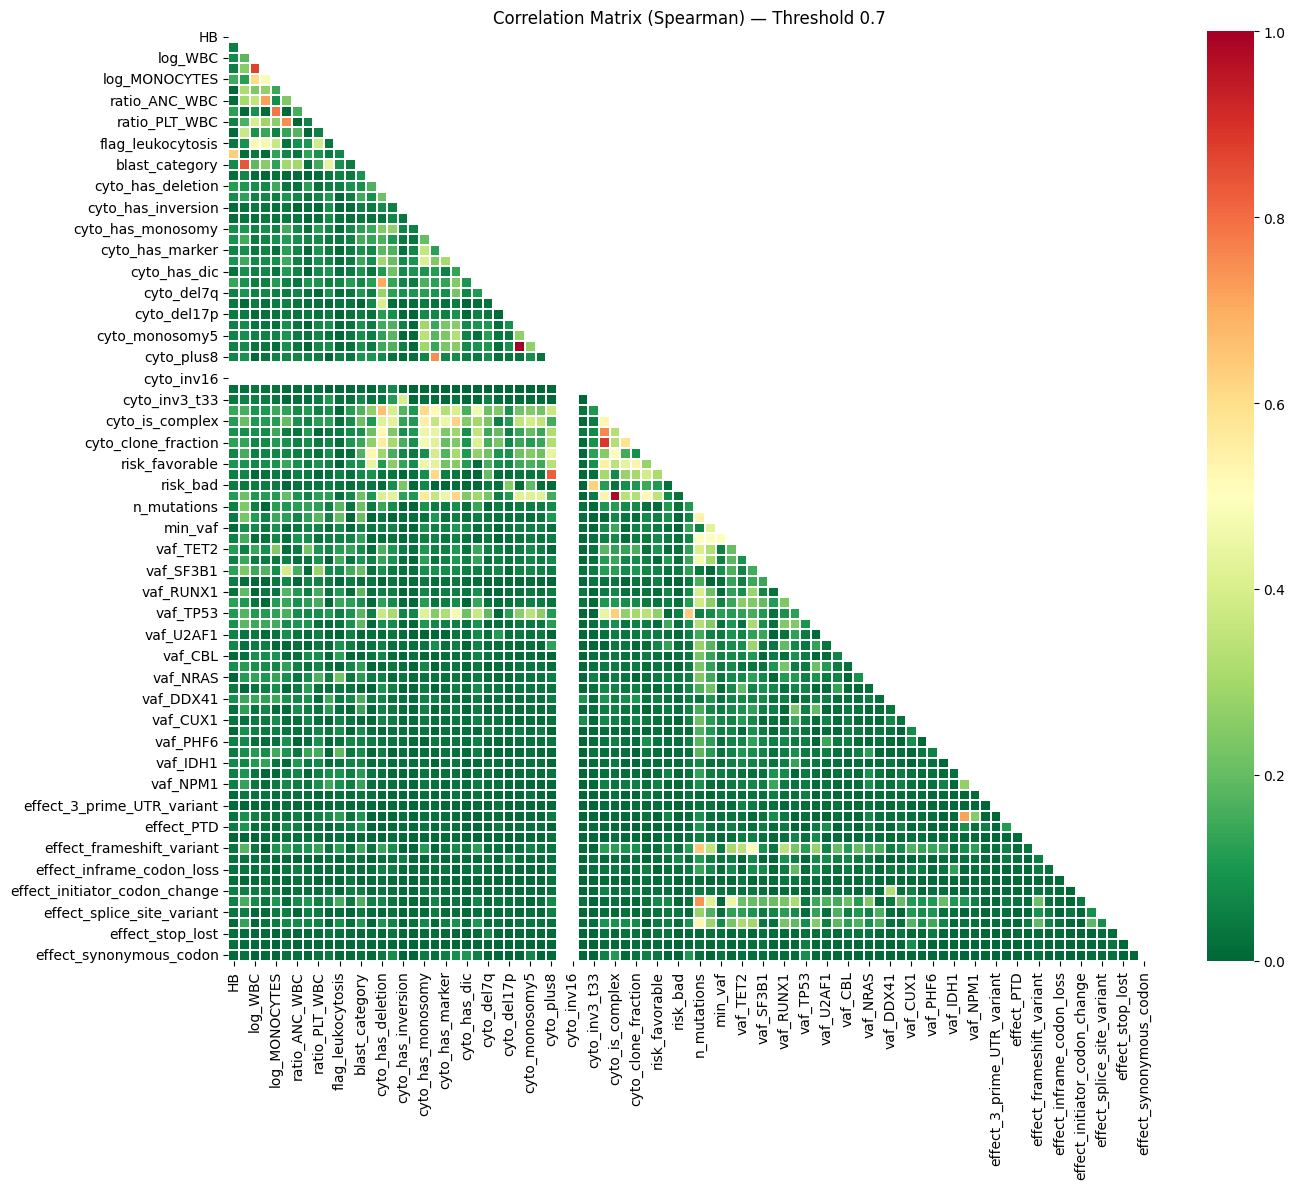

/!\  High Correlation: log_WBC ↔ log_ANC  (0.869)
/!\  High Correlation: log_ANC ↔ ratio_ANC_WBC  (0.719)
/!\  High Correlation: log_MONOCYTES ↔ ratio_MONO_WBC  (0.786)
/!\  High Correlation: log_PLT ↔ ratio_PLT_WBC  (0.752)
/!\  High Correlation: log_BM_BLAST ↔ blast_category  (0.839)
/!\  High Correlation: cyto_has_deletion ↔ cyto_del5q  (0.702)
/!\  High Correlation: cyto_monosomy7 ↔ cyto_monosomy17  (1.000)
/!\  High Correlation: cyto_has_trisomy ↔ cyto_plus8  (0.749)
/!\  High Correlation: cyto_n_anomalies ↔ cyto_n_clones  (0.759)
/!\  High Correlation: cyto_n_anomalies ↔ cyto_clone_fraction  (0.885)
/!\  High Correlation: cyto_plus8 ↔ risk_intermediate  (0.821)
/!\  High Correlation: cyto_is_complex ↔ risk_very_bad  (0.983)
/!\  High Correlation: vaf_FLT3 ↔ effect_ITD  (0.719)
/!\  High Correlation: n_mutations ↔ effect_non_synonymous_codon  (0.742)

Features to delete (high colinearity) : ['log_ANC', 'ratio_ANC_WBC', 'ratio_MONO_WBC', 'ratio_PLT_WBC', 'blast_category', 'cyto_del

In [15]:
# Colinearity tests
def handle_collinearity(df, feature_cols, threshold, method='spearman'):
    X = df[feature_cols].copy()

    # Correlation matrix
    if method == 'spearman':
        corr_matrix = X.corr(method='spearman').abs()
    else:
        corr_matrix = X.corr().abs()

    # Matrix Plot
    plt.figure(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, cmap='RdYlGn_r', center=0.5,
                vmin=0, vmax=1, annot=False, linewidths=0.3)
    plt.title(f"Correlation Matrix (Spearman) — Threshold {threshold}")
    plt.tight_layout()
    plt.show()

    # Identify problematic pairs
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_candidates = []
    for col in upper_tri.columns:
        correlated_with = upper_tri.index[upper_tri[col] > threshold].tolist()
        if correlated_with:
            for other in correlated_with:
                print(f"/!\  High Correlation: {other} ↔ {col}  ({corr_matrix.loc[other, col]:.3f})")
            to_drop_candidates.append(col)

    print(f"\nFeatures to delete (high colinearity) : {to_drop_candidates}")

    return to_drop_candidates

# Colonnes features (sans ID, CENTER, et target)
TARGET_COLS = ['OS_YEARS', 'OS_STATUS']
EXCLUDE    = ['ID', 'CENTER'] + TARGET_COLS
FEAT_COLS  = [c for c in train_clean.columns if c not in EXCLUDE]

candidates_drop = handle_collinearity(train_clean, FEAT_COLS, threshold=0.70)

In [16]:
X = train
X_submission = test

print(f"Dataset train final: {X.shape}")
print(f"Dataset test final : {X_submission.shape}")
print(DROP_COLS)

Dataset train final: (3323, 122)
Dataset test final : (1193, 122)
['WBC', 'ANC', 'BM_BLAST', 'PLT', 'MONOCYTES', 'mut_TET2', 'mut_ASXL1', 'mut_SF3B1', 'mut_DNMT3A', 'mut_RUNX1', 'mut_SRSF2', 'mut_TP53', 'mut_STAG2', 'mut_U2AF1', 'mut_EZH2', 'mut_CBL', 'mut_BCOR', 'mut_NRAS', 'mut_ZRSR2', 'mut_DDX41', 'mut_IDH2', 'mut_CUX1', 'mut_NF1', 'mut_PHF6', 'mut_KRAS', 'mut_IDH1', 'mut_FLT3', 'mut_NPM1', 'flag_thrombocytopenia', 'flag_neutropenia', 'cyto_is_normal', 'n_unique_genes', 'mean_vaf']


In [17]:
# Normality Test (Shapiro-Wilk on samples)
print("Shapiro-Wilk Normality Test: ")
from scipy.stats import shapiro
for col in ['log_WBC', 'log_ANC', 'log_BM_BLAST', 'WBC', 'ANC', 'PLT', 'log_PLT']:
    sample = train[col].dropna().sample(min(500, len(train)), random_state=42)
    stat, p = shapiro(sample)
    normal = "Normal" if p > 0.05 else "Non-normal"
    print(f"{col:20s}: W={stat:.4f}, p={p:.4f} → {normal}")

Shapiro-Wilk Normality Test: 
log_WBC             : W=0.9276, p=0.0000 → Non-normal
log_ANC             : W=0.9620, p=0.0000 → Non-normal
log_BM_BLAST        : W=0.9689, p=0.0000 → Non-normal
WBC                 : W=0.5501, p=0.0000 → Non-normal
ANC                 : W=0.6510, p=0.0000 → Non-normal
PLT                 : W=0.8325, p=0.0000 → Non-normal
log_PLT             : W=0.9853, p=0.0001 → Non-normal


# Step 5: Modelisation

In [18]:
# TARGET PREPARATION
target_df.dropna(subset=['OS_YEARS', 'OS_STATUS'], inplace=True) # Drop rows where 'OS_YEARS' is NaN if conversion caused any issues
print(target_df[['OS_STATUS', 'OS_YEARS']].dtypes) # Check the data types to ensure 'OS_STATUS' is boolean and 'OS_YEARS' is numeric
target_df['OS_YEARS'] = pd.to_numeric(target_df['OS_YEARS'], errors='coerce') # Convert 'OS_YEARS' to numeric if it isn’t already
target_df['OS_STATUS'] = target_df['OS_STATUS'].astype(bool) # Ensure 'OS_STATUS' is boolean

#for the SVM (0 not supported)#
target_df.loc[target_df['OS_YEARS'] <= 0, 'OS_YEARS'] = 0.001 

y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)
                        
# Format features
X = X.loc[X['ID'].isin(target_df['ID'])]

features_to_drop = ['ID', 'CENTER']
X = X.drop(columns=features_to_drop)
X_eval = X_submission.drop(columns=features_to_drop)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

OS_STATUS    float64
OS_YEARS     float64
dtype: object


In [19]:
# STANDARDISATION for linear models

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns)
X_eval_scaled = pd.DataFrame(scaler.transform(X_eval), columns=X_eval.columns)
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Columns for Cox Net
cols_cox = ['BM_BLAST', 'HB', 'PLT', 'n_mutations']

# Columns for other models
X_train_filtered = X_train_scaled.drop(columns=DROP_COLS)
X_test_filtered = X_test_scaled.drop(columns=DROP_COLS)
X_eval_filtered = X_eval_scaled.drop(columns=DROP_COLS)

In [20]:
# MODELS & PARAMETERS

configs = [
    {
        "name": "CoxPH (Simple Clinic)",
        "model": CoxPHSurvivalAnalysis(),
        "params": {'alpha': [0, 0.001, 0.01, 0.1, 1.0]},
        "data_train": X_train_scaled[cols_cox], # Only 4 columns
        "data_test": X_test_scaled[cols_cox],
        "data_eval": X_eval_scaled[cols_cox]
    },
    {
        "name": "Coxnet (ElasticNet Full)",
        "model": CoxnetSurvivalAnalysis(l1_ratio=0.5),
        "params": {
            'alpha_min_ratio': [0.05, 0.01, 0.005, 0.001],
            'n_alphas': [100],
            'l1_ratio': [0.1, 0.5, 0.9]
        },
        "data_train": X_train_scaled.drop(columns=DROP_COLS),
        "data_test": X_test_scaled.drop(columns=DROP_COLS),
        "data_eval": X_eval_scaled.drop(columns=DROP_COLS)
    },
    {
        "name": "Random Survival Forest",
        "model": RandomSurvivalForest(random_state=42),
        "params": {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 7, 10],
            'min_samples_leaf': [5, 15, 30]
        },
        "data_train": X_train.drop(columns=DROP_COLS),
        "data_test": X_test.drop(columns=DROP_COLS),
        "data_eval": X_eval.drop(columns=DROP_COLS)
    },
    {
        "name": "Extra Survival Trees",
        "model": ExtraSurvivalTrees(random_state=42),
        "params": {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, 15],
            'min_samples_split': [10, 20]
        },
        "data_train": X_train.drop(columns=DROP_COLS),
        "data_test": X_test.drop(columns=DROP_COLS),
        "data_eval": X_eval.drop(columns=DROP_COLS)
    },
    {
        "name": "Componentwise GB",
        "model": ComponentwiseGradientBoostingSurvivalAnalysis(random_state=42),
        "params": {
            'n_estimators': [100, 300, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.8, 1.0]
        },
        "data_train": X_train_scaled.drop(columns=DROP_COLS),
        "data_test": X_test_scaled.drop(columns=DROP_COLS),
        "data_eval": X_eval_scaled.drop(columns=DROP_COLS)
    },
    {
        "name": "Gradient Boosting (Trees)",
        "model": GradientBoostingSurvivalAnalysis(random_state=42),
        "params": {
            'n_estimators': [100, 300],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 4], 
        },
        "data_train": X_train.drop(columns=DROP_COLS),
        "data_test": X_test.drop(columns=DROP_COLS),
        "data_eval": X_eval.drop(columns=DROP_COLS)
    },
    {
        "name": "FastSurvivalSVM",
        "model": FastSurvivalSVM(max_iter=1000, random_state=42),
        "params": {
            'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
            'optimizer': ['avltree', 'rbtree'], # Test de deux types d'arbres de recherche
            'rank_ratio': [0.5, 0.8, 1.0],      # Equilibre entre rang et temps
            'fit_intercept': [True, False]      # Essentiel pour certains datasets scalés
        },
        "data_train": X_train_scaled.drop(columns=DROP_COLS),
        "data_test": X_test_scaled.drop(columns=DROP_COLS),
        "data_eval": X_eval_scaled.drop(columns=DROP_COLS)
    },
]

In [21]:
# TRAINING AND EVALUTION: use of C-index score because more stable for CV
import time

summary_results = []
eval_predictions = {}
best_models = {}

for cfg in configs:
    print(f"\n--- Training : {cfg['name']} ---")
    start_time = time.time()
    
    #Cross Validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    gscv = GridSearchCV(cfg["model"], cfg["params"], cv=cv, n_jobs=-1)
    
    # Training
    gscv.fit(cfg["data_train"], y_train)
    best_m = gscv.best_estimator_
    best_models[cfg["name"]] = best_m 

    elapsed_time = time.time() - start_time
    
    # Evalutaion
    train_score = gscv.best_score_
    test_score = best_m.score(cfg["data_test"], y_test)
    
    print(f"✅ Ended with : {elapsed_time:.2f} secondes")
    print(f"✅ Params : {gscv.best_params_}")
    print(f"📊 C-Index -> Train (CV): {train_score:.4f} | Test: {test_score:.4f}")

    # FEATURE IMPORTANCE when possible
    try:
        importances = None
        
        # For Componentwise Gradient Boosting (Intercept to remove)
        if cfg["name"] == "Componentwise GB":
            coef_vals = best_m.coef_
            importances = pd.Series(coef_vals[1:], index=cfg["data_train"].columns)

        # for SVM model
        elif cfg["name"] == "FastSurvivalSVM":
            coef_vals = best_m.coef_
            importances_svm = pd.Series(coef_vals, index=cfg["data_train"].columns)
            
        # For Cox, Coxnet models
        elif hasattr(best_m, "coef_"):
            coef_vals = best_m.coef_ if best_m.coef_.ndim == 1 else best_m.coef_[:, -1]
            importances = pd.Series(coef_vals, index=cfg["data_train"].columns)
            
        # For tree models (feature_importances_)
        elif hasattr(best_m, "feature_importances_"):
            importances = pd.Series(best_m.feature_importances_, index=cfg["data_train"].columns)

        if importances is not None:
            top_20_idx = importances.abs().sort_values(ascending=False).head(20).index
            df_top_20 = pd.DataFrame({
                'Feature': top_20_idx,
                'Value': importances.loc[top_20_idx].values
            })
            print(f"\n🔝 TOP 20 FEATURES :")
            print(df_top_20.to_string(index=False))
            
    except Exception as e:
        print(f"/!\ Error with the feature importance extraction: {e}")
    
    summary_results.append({
        "Model": cfg["name"],
        "Train_Score": train_score,
        "Test_Score": test_score
    })
    
    # Prediction
    eval_predictions[cfg["name"]] = best_m.predict(cfg["data_eval"])

summary_df = pd.DataFrame(summary_results).sort_values(by="Test_Score", ascending=False)
print("\n--- Model ranking ---")
print(summary_df)



--- Training : CoxPH (Simple Clinic) ---
✅ Ended with : 18.87 secondes
✅ Params : {'alpha': 1.0}
📊 C-Index -> Train (CV): 0.6962 | Test: 0.7099

🔝 TOP 20 FEATURES :
    Feature     Value
         HB -0.354377
n_mutations  0.282235
        PLT -0.265215
   BM_BLAST  0.234688

--- Training : Coxnet (ElasticNet Full) ---
✅ Ended with : 3.60 secondes
✅ Params : {'alpha_min_ratio': 0.05, 'l1_ratio': 0.1, 'n_alphas': 100}
📊 C-Index -> Train (CV): 0.7349 | Test: 0.7341

🔝 TOP 20 FEATURES :
                    Feature     Value
                         HB -0.234623
                   vaf_TP53  0.209755
                    log_PLT -0.159577
               log_BM_BLAST  0.142790
                  vaf_ASXL1  0.127072
             risk_favorable -0.103319
           cyto_n_anomalies  0.101363
effect_non_synonymous_codon  0.096760
                n_mutations  0.087333
                  vaf_RUNX1  0.072355
                 effect_PTD  0.067979
                 vaf_DNMT3A  0.060946
                 

c:\Users\lea.coquet\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
60 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\lea.coquet\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\lea.coquet\AppData\Local\Programs\Python\Python39\lib\site-packages\sksurv\svm\survival_svm.py", line 755, in fit
    raise ValueError("fit_intercept=True is only meaningful if rank_ratio < 1.0")
ValueError: fit_intercept=Tr

✅ Ended with : 197.69 secondes
✅ Params : {'alpha': 0.1, 'fit_intercept': False, 'optimizer': 'rbtree', 'rank_ratio': 1.0}
📊 C-Index -> Train (CV): 0.7271 | Test: 0.7331

--- Model ranking ---
                       Model  Train_Score  Test_Score
4           Componentwise GB     0.735982    0.737713
2     Random Survival Forest     0.736181    0.736971
3       Extra Survival Trees     0.729953    0.735242
1   Coxnet (ElasticNet Full)     0.734855    0.734103
6            FastSurvivalSVM     0.727059    0.733096
5  Gradient Boosting (Trees)     0.731031    0.732865
0      CoxPH (Simple Clinic)     0.696151    0.709950


In [407]:
### CGB ON THE FULL DATASET

params_CGB = {'learning_rate': 0.1, 'n_estimators': 300, 'subsample': 0.8}

model_CGB = ComponentwiseGradientBoostingSurvivalAnalysis(**params_CGB, random_state=42)

model_CGB.fit(X_scaled.drop(columns=DROP_COLS), y)

pred_CGB_final = model_CGB.predict(X_eval_scaled.drop(columns=DROP_COLS))

pd.DataFrame({
    'ID': X_submission['ID'],
    'risk_score': pred_CGB_final
}).to_csv('submissions_results/submission_full_dataset_cgb.csv', index=False)

In [492]:
### GBSA on THE FULL DATASET

params_GBSA = {'n_estimators':300, 'learning_rate':0.05, 'max_depth' : 3}

model_GBSA = GradientBoostingSurvivalAnalysis(**params_GBSA, random_state=42)

model_GBSA.fit(X.drop(columns=DROP_COLS), y)

pred_GBSA_final = model_GBSA.predict(X_eval.drop(columns=DROP_COLS))

pd.DataFrame({
    'ID': X_submission['ID'],
    'risk_score': pred_GBSA_final
}).to_csv('submissions_results/submission_full_dataset_gbsa.csv', index=False)

In [32]:
### Deep Surv

# Katzman in deepsurv recommends deep architecture with few neurons to avoid overfitting
n_features = X_train_scaled.shape[1]  # Number of features
num_nodes = [32, 16]                  # 2 hidden layers(standard Cox-MLP)
output_size = 1                       # output size
batch_norm = True                     # normalize data at each step
dropout = 0.5                        # Regularisation
output_bias = False

# MLP Vanilla architecture used by Katzman
net = tt.practical.MLPVanilla(n_features, num_nodes, output_size, batch_norm, dropout)
optimizer = torch.optim.Adam(net.parameters(), lr=0.001, weight_decay=1e-4)

# Format data
x_train_nn = X_train_scaled.values.astype('float32')
x_test_nn = X_test_scaled.values.astype('float32')
y_train_nn = (y_train['OS_YEARS'].astype('float32'), y_train['OS_STATUS'].astype('float32'))
y_test_nn = (y_test['OS_YEARS'].astype('float32'), y_test['OS_STATUS'].astype('float32'))

x_eval_nn = X_eval_scaled.values.astype('float32')

# Training
model = CoxPH(net, torch.optim.Adam)
model.optimizer.set_lr(0.001)
batch_size = 256
epochs = 500

callbacks = [tt.callbacks.EarlyStopping(patience=25)]

print("--- Training of the model")
model.fit(x_train_nn, y_train_nn, batch_size, epochs, callbacks, val_data=(x_test_nn, y_test_nn), verbose=True)

# Evaluation
_ = model.compute_baseline_hazards()
surv = model.predict_surv_df(x_test_nn)
ev = EvalSurv(surv, y_test_nn[0], y_test_nn[1], censor_surv='km')
print(f"\nC-Index : {ev.concordance_td():.4f}")

--- Training of the model
0:	[0s / 0s],		train_loss: 4.9652,	val_loss: 6.0616
1:	[0s / 0s],		train_loss: 5.0288,	val_loss: 6.0102
2:	[0s / 0s],		train_loss: 4.9117,	val_loss: 5.9705
3:	[0s / 0s],		train_loss: 4.7960,	val_loss: 5.9429
4:	[0s / 0s],		train_loss: 4.7690,	val_loss: 5.9219
5:	[0s / 0s],		train_loss: 4.7215,	val_loss: 5.9053
6:	[0s / 0s],		train_loss: 4.6875,	val_loss: 5.8895
7:	[0s / 0s],		train_loss: 4.6800,	val_loss: 5.8793
8:	[0s / 0s],		train_loss: 4.6741,	val_loss: 5.8690
9:	[0s / 0s],		train_loss: 4.6972,	val_loss: 5.8586
10:	[0s / 1s],		train_loss: 4.6196,	val_loss: 5.8482
11:	[0s / 1s],		train_loss: 4.6281,	val_loss: 5.8411
12:	[0s / 1s],		train_loss: 4.6079,	val_loss: 5.8340
13:	[0s / 1s],		train_loss: 4.5650,	val_loss: 5.8286
14:	[0s / 1s],		train_loss: 4.5957,	val_loss: 5.8244
15:	[0s / 1s],		train_loss: 4.5730,	val_loss: 5.8185
16:	[0s / 1s],		train_loss: 4.5666,	val_loss: 5.8129
17:	[0s / 1s],		train_loss: 4.5413,	val_loss: 5.8077
18:	[0s / 1s],		train_loss: 4.

# Step 6: Stacking & Final submission

In [ ]:
### Stacking
# Collecting best parameter from the gridsearch
params_CGB = {'learning_rate': 0.1, 'n_estimators': 300, 'subsample': 0.8}
params_extra = {'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 300}
params_coxnet = {'alpha_min_ratio': 0.05, 'l1_ratio': 0.1, 'n_alphas': 100}
params_gbtree = {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}

# Models
model_CGB = ComponentwiseGradientBoostingSurvivalAnalysis(**params_CGB, random_state=42)
model_extra = ExtraSurvivalTrees(**params_extra, random_state=42, n_jobs=-1)
model_coxnet = CoxnetSurvivalAnalysis(**params_coxnet)
model_gbtree = GradientBoostingSurvivalAnalysis(random_state=42)

# Training
model_CGB.fit(X_train_scaled.drop(columns=DROP_COLS), y_train)
model_extra.fit(X_train.drop(columns=DROP_COLS), y_train)
model_coxnet.fit(X_train_scaled.drop(columns=DROP_COLS), y_train)
model_gbtree.fit(X_train.drop(columns=DROP_COLS), y_train)

# New predictions
pred_CGB_test = model_CGB.predict(X_test_scaled.drop(columns=DROP_COLS))
pred_extra_test = model_extra.predict(X_test.drop(columns=DROP_COLS))
pred_coxnet_test = model_coxnet.predict(X_test_scaled.drop(columns=DROP_COLS))
pred_gbtree_test = model_gbtree.predict(X_test.drop(columns=DROP_COLS))

df_meta_test = pd.DataFrame({
    'm_CGB': pred_CGB_test,
    'm_ExtraTrees': pred_extra_test,
    'm_Coxnet': pred_coxnet_test,
    "m_gbtree": pred_gbtree_test})

# Training of the meta-modele (Cox simple)
meta_cox = CoxPHSurvivalAnalysis()
meta_cox.fit(df_meta_test, y_test)

stacked_risk_test = meta_cox.predict(df_meta_test)

# Scores comparison
c_cgb = concordance_index_censored(y_test["OS_STATUS"], y_test["OS_YEARS"], pred_CGB_test)[0]
c_extratrees = concordance_index_censored(y_test["OS_STATUS"], y_test["OS_YEARS"], pred_extra_test)[0]
c_coxnet = concordance_index_censored(y_test["OS_STATUS"], y_test["OS_YEARS"], pred_coxnet_test)[0]
c_gbtree = concordance_index_censored(y_test["OS_STATUS"], y_test["OS_YEARS"], pred_gbtree_test)[0]
c_stacked = concordance_index_censored(y_test["OS_STATUS"], y_test["OS_YEARS"], stacked_risk_test)[0]

print(f"C-Index CGB : {c_cgb:.4f}")
print(f"C-Index Extra Trees : {c_extratrees:.4f}")
print(f"C-Index Coxnet : {c_coxnet:.4f}")
print(f"C-Index gbtree : {c_gbtree:.4f}")
print("-" * 35)
print(f"C-Index STACKING      : {c_stacked:.4f}")

meta_weights = pd.Series(meta_cox.coef_, index=df_meta_test.columns)
print("\nStacking weight per model :")
print(meta_weights)

C-Index CGB : 0.7376
C-Index Extra Trees : 0.7351
C-Index Coxnet : 0.7341
C-Index gbtree : 0.7330
-----------------------------------
C-Index STACKING      : 0.7408

Stacking weight per model :
m_CGB           0.221890
m_ExtraTrees    0.001248
m_Coxnet       -0.006141
m_gbtree        0.377570
dtype: float64


In [ ]:
### STACKING ON THE FULL DATASET with CV
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Collecting best parameter from the gridsearch
params_CGB = {'learning_rate': 0.1, 'n_estimators': 300, 'subsample': 0.8}
params_extra = {'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 300}
params_coxnet = {'alpha_min_ratio': 0.05, 'l1_ratio': 0.1, 'n_alphas': 100}
params_gbtree = {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}

# Models
model_CGB = ComponentwiseGradientBoostingSurvivalAnalysis(**params_CGB, random_state=42)
model_extra = ExtraSurvivalTrees(**params_extra, random_state=42, n_jobs=-1)
model_coxnet = CoxnetSurvivalAnalysis(**params_coxnet)
model_gbtree = GradientBoostingSurvivalAnalysis(random_state=42)

# OOF predictions
oof_cgb = np.zeros(X.shape[0])
oof_extra = np.zeros(X.shape[0])
oof_coxnet = np.zeros(X.shape[0])
oof_gbtree = np.zeros(X.shape[0])

# Submission predictions
sub_cgb_list = []
sub_extra_list = []
sub_coxnet_list = []
sub_gbtree_list = []

print(f"--- CV-Stacking on full dataset ({n_splits} folds) ---")

# Cross validation
for i, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"Processing Fold {i+1}...")
    
    # Split
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    X_tr_sc, X_val_sc = X_scaled.iloc[train_idx], X_scaled.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    # Training
    model_CGB.fit(X_tr_sc.drop(columns=DROP_COLS), y_tr)
    model_extra.fit(X_tr.drop(columns=DROP_COLS), y_tr)
    model_coxnet.fit(X_tr_sc.drop(columns=DROP_COLS), y_tr)
    model_gbtree.fit(X_tr.drop(columns=DROP_COLS), y_tr)
    
    # Out-of-Fold Predictions
    oof_cgb[val_idx] = model_CGB.predict(X_val_sc.drop(columns=DROP_COLS))
    oof_extra[val_idx] = model_extra.predict(X_val.drop(columns=DROP_COLS))
    oof_coxnet[val_idx] = model_coxnet.predict(X_val_sc.drop(columns=DROP_COLS))
    oof_gbtree[val_idx] = model_gbtree.predict(X_val.drop(columns=DROP_COLS))
    
    # X_eval predictions
    sub_cgb_list.append(model_CGB.predict(X_eval_scaled.drop(columns=DROP_COLS)))
    sub_extra_list.append(model_extra.predict(X_eval.drop(columns=DROP_COLS)))
    sub_coxnet_list.append(model_coxnet.predict(X_eval_scaled.drop(columns=DROP_COLS)))
    sub_gbtree_list.append(model_gbtree.predict(X_eval.drop(columns=DROP_COLS)))

# Training of the final meta model
df_oof_train = pd.DataFrame({
    'm_CompGB': oof_cgb,
    'm_ExtraTrees': oof_extra,
    'm_Coxnet': oof_coxnet,
    'm_gbtree': oof_gbtree
})

meta_cox_final = CoxPHSurvivalAnalysis()
meta_cox_final.fit(df_oof_train, y)

print("\n Stacking weights :")
print(pd.Series(meta_cox_final.coef_, index=df_oof_train.columns))

# Final prediction
mean_pred_cgb = np.mean(sub_cgb_list, axis=0)
mean_pred_extra = np.mean(sub_extra_list, axis=0)
mean_pred_coxnet = np.mean(sub_coxnet_list, axis=0)
mean_pred_gbtree = np.mean(sub_gbtree_list, axis=0)

df_meta_eval = pd.DataFrame({
    'm_CompGB': mean_pred_cgb,
    'm_ExtraTrees': mean_pred_extra,
    'm_Coxnet': mean_pred_coxnet,
    'm_gbtree': mean_pred_gbtree,
})

final_ultimate_risk = meta_cox_final.predict(df_meta_eval)

# exportation
submission_stacking = pd.DataFrame({'ID': X_submission['ID'],'risk_score': final_ultimate_risk})
submission_stacking.to_csv('submissions_results/submission_ULTIMATE_CV_STACKING_V2.csv', index=False)

--- CV-Stacking on full dataset (5 folds) ---
Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Processing Fold 5...

 Stacking weights :
m_CompGB        0.741306
m_ExtraTrees    0.000482
m_Coxnet       -0.175358
m_gbtree        0.308287
dtype: float64


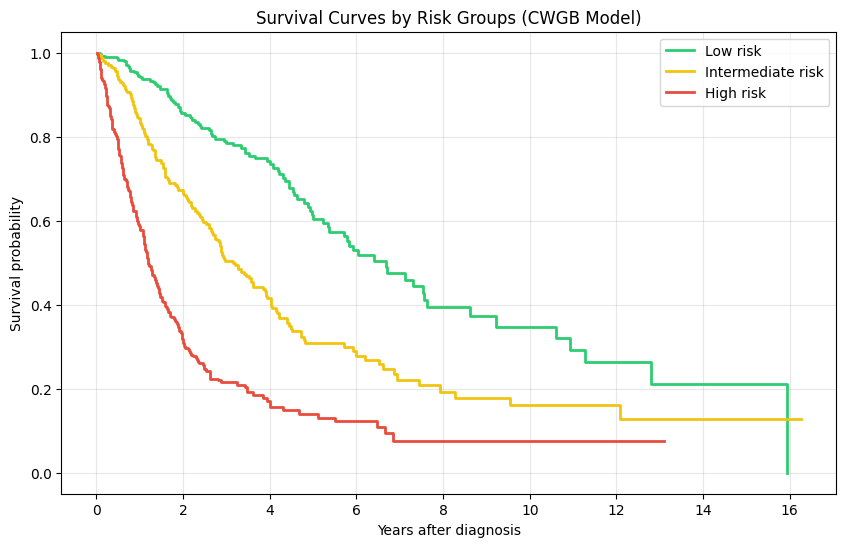

In [34]:
# Medical validation with KAPLAN-MEIER

# Predictions with the best model ComponentwiseGradientBoostingSurvivalAnalysis
risk_test = best_models["Componentwise GB"].predict(X_test_scaled.drop(columns=DROP_COLS))

# 3 groups of patients
thresholds = np.percentile(risk_test, [33, 66])
groups = np.digitize(risk_test, thresholds)

labels = ["Low risk", "Intermediate risk", "High risk"]
colors = ["#2ecc71", "#f1c40f", "#e74c3c"]

plt.figure(figsize=(10, 6))

for i in range(3):
    mask = (groups == i)
    time, survival_prob = kaplan_meier_estimator(y_test["OS_STATUS"][mask], y_test["OS_YEARS"][mask])
    plt.step(time, survival_prob, where="post", label=labels[i], color=colors[i], lw=2)

plt.title("Survival Curves by Risk Groups (CWGB Model)")
plt.xlabel("Years after diagnosis")
plt.ylabel("Survival probability")
plt.legend()
plt.grid(alpha=0.3)
plt.show()